# Estimating a circuit with a non-surface CSS code

This example estimates a small random Clifford+T circuit using the Steane `[[7, 1, 3]]` code as the computational `CodePatch`. It demonstrates the full flow: define a circuit, provide qLDPC-verified logical Clifford implementations, compile to fault-tolerant primitives, and estimate physical operation costs.

## Current assumptions

- H and S are implemented by explicit physical Stim circuits whose logical action is verified by qLDPC.
- CNOT is costed as a blockwise transversal CNOT between identical CSS code blocks.
- T-state cultivation still uses the existing surface-code cost model. Conversion from that surface-code patch into the Steane computational code is currently assigned zero cost.
- The example supplies known Steane circuits rather than asking qLDPC to discover them, so running the notebook does not require GAP or Magma.

In [1]:
from collections import Counter
from pathlib import Path
import sys
import warnings

import cirq
import stim

# Make the repository importable whether the notebook is launched from the
# repository root or from the notebooks directory.
for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / "resource_estimation").is_dir():
        repo_root = candidate
        break
else:
    raise RuntimeError("Run this notebook from the resource-superstaq repository.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import resource_estimation.ftqc as ftqc
from resource_estimation.ftqc.architecture import MissingLogicalGateCostWarning
from resource_estimation.ftqc.logical_operations import CSSLogicalOperations

## Create a deterministic random circuit

The fixed seed makes the example reproducible and produces at least one H, S, T, and CNOT. A final measurement is appended explicitly.

In [2]:
logical_circuit = cirq.testing.random_circuit(
    qubits=3,
    n_moments=6,
    op_density=0.9,
    gate_domain={cirq.H: 1, cirq.S: 1, cirq.T: 1, cirq.CNOT: 2},
    random_state=1,
)

required_gate_families = {
    "H": cirq.GateFamily(cirq.H),
    "S": cirq.GateFamily(cirq.S),
    "T": cirq.GateFamily(cirq.T),
    "CNOT": cirq.GateFamily(cirq.CNOT),
}
present_gates = {
    name: any(op in family for op in logical_circuit.all_operations())
    for name, family in required_gate_families.items()
}
assert all(present_gates.values()), present_gates

logical_circuit.append(cirq.measure(*sorted(logical_circuit.all_qubits()), key="result"))
print("Required gates present:", present_gates)
logical_circuit

Required gates present: {'H': True, 'S': True, 'T': True, 'CNOT': True}


0: ───T───X───@───X───H───@───M('result')───
          │   │   │       │   │
1: ───H───┼───X───@───S───X───M─────────────
          │                   │
2: ───────@───────S───────────M─────────────

## Define the Steane computational patch

`CodePatch` obtains the code matrices and metadata from qLDPC. Movement architectures currently accept binary, stabilizer CSS codes with one logical qubit and a known distance.

In [3]:
patch = ftqc.CodePatch("steane")
assert patch.code_params == (7, 1, 3)

patch_summary = {
    "[n, k, d]": patch.code_params,
    "data qubits": patch.num_data_qubits,
    "measurement qubits": patch.num_measure_qubits,
    "physical qubits per block": patch.num_physical_qubits,
    "binary CSS stabilizer": (patch.is_binary, patch.is_css, patch.is_stabilizer_code),
}
for label, value in patch_summary.items():
    print(f"{label:28} {value}")

[n, k, d]                    (7, 1, 3)
data qubits                  7
measurement qubits           6
physical qubits per block    13
binary CSS stabilizer        (True, True, True)


## Supply and verify transversal H and S

For this Steane-code convention, physical H on every data qubit implements logical H, while physical S† on every data qubit implements logical S. `CSSLogicalOperations.from_circuits` checks both claims by calculating their logical tableaus with qLDPC.

In [4]:
physical_h = stim.Circuit()
physical_h.append("H", range(patch.n))

physical_s = stim.Circuit()
physical_s.append("S_DAG", range(patch.n))

logical_operations = CSSLogicalOperations.from_circuits(
    patch,
    h_circuit=physical_h,
    s_circuit=physical_s,
)
print("Logical H implementation:", logical_operations.h_circuit, sep="\n")
print("Logical S implementation:", logical_operations.s_circuit, sep="\n")

Logical H implementation:
H 0 1 2 3 4 5 6
Logical S implementation:
S_DAG 0 1 2 3 4 5 6


## Configure the movement architecture and compile

The computational blocks use the Steane patch. One T factory is included because the random circuit contains T gates. Syndrome extraction is performed after logical operations, while idle-qubit correction is disabled to keep the example compact.

SingleSpeciesMovement(d=3, cr=1, fd=3, sr=1, fold=False)
Compiled moments: 33
Logical primitive counts:
  SE(1)              22
  MOVE_IZ            20
  MOVE_MZ            8
  CNOT               5
  S                  3
  H                  2
  CULT(0.785)        1
  cirq.MeasurementGate(1, cirq.MeasurementKey(name=''), ()) 1
  reset              1
  cirq.MeasurementGate(3, cirq.MeasurementKey(name='result'), ()) 1


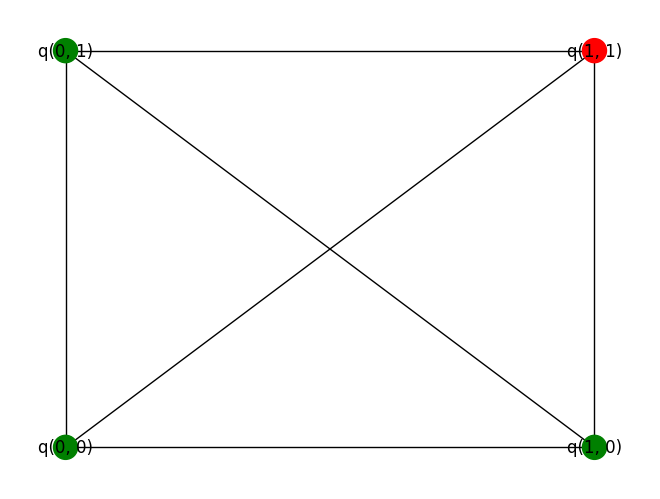

In [9]:
architecture = ftqc.DefaultMovement(
    patch=patch,
    logical_operations=logical_operations,
    idling=False,
    post_op_correction=True,
    syndrome_rounds=1,
)
layout = ftqc.MovementLayout(input_circuit=logical_circuit, num_t_factories=1)
layout.draw()
primitive_circuit = ftqc.ft_compile(layout=layout, arc=architecture, verbose=0)

assert all(architecture.primitives.validate(op) for op in primitive_circuit.all_operations())
primitive_counts = Counter(str(op.gate) for op in primitive_circuit.all_operations())
print(architecture)
print(f"Compiled moments: {len(primitive_circuit)}")
print("Logical primitive counts:")
for primitive, count in primitive_counts.most_common():
    print(f"  {primitive:18} {count}")

## Estimate physical resources

Serial counts represent all physical operations. Critical-path counts and time represent the longest scheduled dependency path through the compiled circuit.

In [6]:
estimator = ftqc.ResourceEstimator(arc=architecture)

with warnings.catch_warnings(record=True) as caught_warnings:
    warnings.simplefilter("always")
    serial_cost = estimator.serial_circuit_cost(primitive_circuit, pretty=True)
    critical_path_cost = estimator.parallel_circuit_cost(primitive_circuit, pretty=True)
    critical_path_time_us = estimator.parallel_circuit_time(primitive_circuit)

missing_cost_warnings = [
    item for item in caught_warnings if issubclass(item.category, MissingLogicalGateCostWarning)
]
assert not missing_cost_warnings
assert serial_cost and critical_path_cost and critical_path_time_us > 0

def print_costs(title, costs):
    print(title)
    for operation, count in sorted(costs.items(), key=lambda item: item[1], reverse=True):
        print(f"  {operation:25} {count:,.0f}")

print_costs("Serial physical-operation counts", serial_cost)
print()
print_costs("Critical-path physical-operation counts", critical_path_cost)

compute_block_qubits = len(logical_circuit.all_qubits()) * patch.num_physical_qubits
print(f"\nCritical-path time: {critical_path_time_us:,.2f} μs")
print(f"Computational-block footprint: {compute_block_qubits} physical qubits")

if caught_warnings:
    print("\nModel warnings:")
    for item in caught_warnings:
        print(f"  {item.category.__name__}: {item.message}")

Serial physical-operation counts
  CZ                        2,312
  PhasedXZGate              1,432
  ResetChannel              673
  MeasurementGate           618
  QubitPermutationGate      562

Critical-path physical-operation counts
  QubitPermutationGate      350
  CZ                        154
  PhasedXZGate              56
  ResetChannel              21
  MeasurementGate           21

Critical-path time: 204,721.58 μs
Computational-block footprint: 39 physical qubits

Model warnings:


## Interpreting the result

The H, S, CNOT, measurement, reset, and syndrome-extraction costs above use the Steane computational patch. T cultivation uses the existing surface-code model; with computational distance 3 and cultivation fault distance 3, that model reports its existing fallback to surface-code distance 7. The adaptation from the cultivated surface patch into Steane is free in the current estimator.

For the same reason, the displayed qubit footprint counts only the three Steane computational blocks. `ResourceEstimator.physical_qubits()` currently applies the computational patch size uniformly to every logical location, so it should not yet be interpreted as a mixed-code device footprint that separately sizes the surface-code T factory.